In [2]:
import sys
import xarray as xr
import numpy as np
from matplotlib import pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature
import geopandas as gpd
from shapely.geometry import mapping
from scipy.stats import spearmanr, pearsonr
import ts_onset_cess as ocd
import pandas as pd
from fapar_def import fapar_read
import gc
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

import warnings
warnings.filterwarnings('ignore')

In [3]:
datap = "/Users/ellendyer/Documents/GitHub/Isotopes_F4R/plots/"
#dataf = "/Volumes/blue_wd/ESA_F4R/fapar/analysed/"
datac = "/Users/ellendyer/Documents/GitHub/Isotopes_F4R/data/"
dataf = "/Users/ellendyer/Documents/GitHub/Isotopes_F4R/data/analysed_fapar/"

In [4]:
fapar = xr.open_mfdataset(dataf+'*_eq.nc')
precip = xr.open_dataset(datac+'chirps_10day_eq.nc') 

In [5]:
fapar = fapar.mean(dim=('lat','lon')).load()
precip = precip.mean(dim=('lat','lon')).load()

In [6]:
fapar_clim = fapar.groupby('time.dayofyear').mean('time')
precip_clim = precip.groupby('time.dayofyear').mean('time')

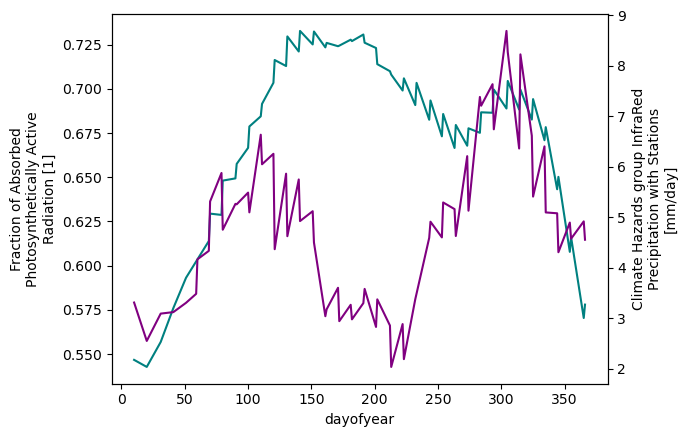

<Figure size 640x480 with 0 Axes>

In [7]:
fig,ax = plt.subplots()
fapar_clim['fAPAR'].plot(color='teal',label='fAPAR',ax=ax)
ax2 = ax.twinx()
precip_clim['precip'].plot(color='purple',label='CHIRPS',ax=ax2)
plt.show()
plt.clf()

In [8]:
fapar_sns = fapar.to_dataframe()
precip_sns = precip.to_dataframe()
df = fapar_sns.join(precip_sns)

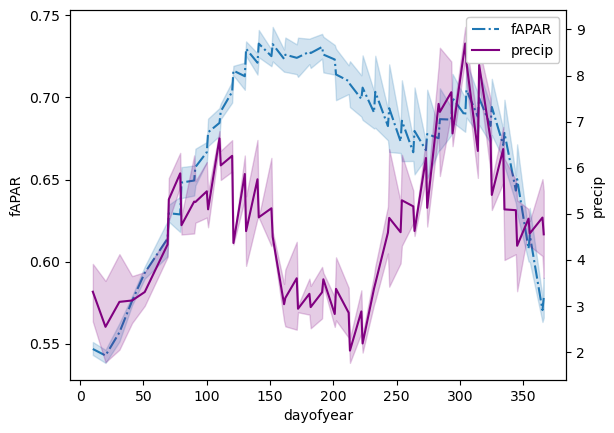

<Figure size 640x480 with 0 Axes>

In [9]:
df_clim = df.copy(deep=True)
df_clim.insert(0, "dayofyear", df_clim.index.dayofyear)
df_clim.insert(0, "year", df_clim.index.year)
fig,ax = plt.subplots()
sns.lineplot(data=df_clim, x="dayofyear", y="fAPAR",ax=ax,linestyle='-.',label='fAPAR')
ax2 = ax.twinx()
sns.lineplot(data=df_clim, x="dayofyear", y="precip",ax=ax2,color='purple',label='precip')
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
plt.legend(lines + lines2, labels + labels2, framealpha=1.0, loc='upper right')
plt.show()
plt.clf()


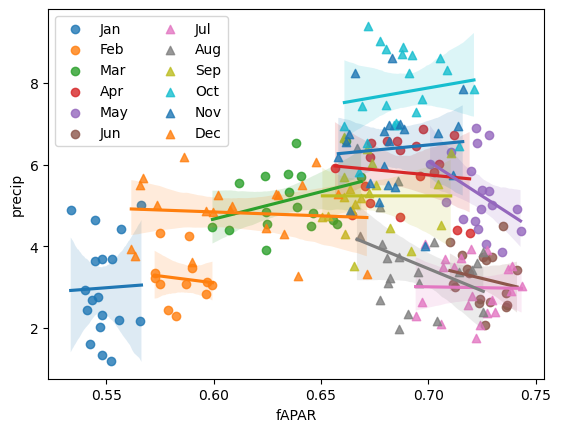

In [10]:
mon = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
shp = ['o','o','o','o','o','o','^','^','^','^','^','^']
for m in range(1,13):
    df_m = df[df.index.month == m]
    sns.regplot(data=df_m, x="fAPAR", y="precip",label=mon[m-1],marker=shp[m-1])
    plt.legend(ncol=2)

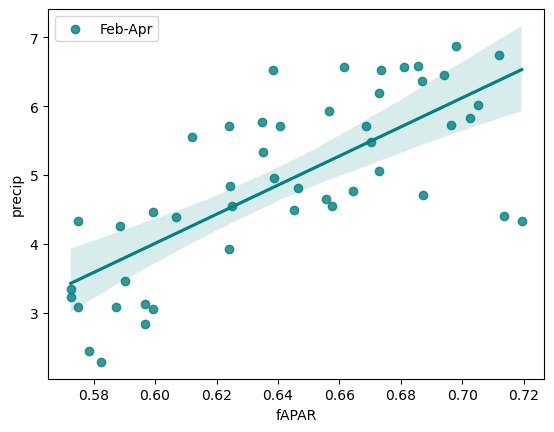

In [11]:
df_seas = df[df.index.month.isin([2,3,4])]
sns.regplot(data=df_seas, x="fAPAR", y="precip",label='Feb-Apr',ci=95,color='teal')
plt.legend()

In [12]:
fit_results = sm.OLS(df_seas['fAPAR'], df_seas['precip']).fit()
print(fit_results.summary())

                                 OLS Regression Results                                
Dep. Variable:                  fAPAR   R-squared (uncentered):                   0.958
Model:                            OLS   Adj. R-squared (uncentered):              0.958
Method:                 Least Squares   F-statistic:                              1085.
Date:                Fri, 22 May 2026   Prob (F-statistic):                    4.01e-34
Time:                        17:08:36   Log-Likelihood:                          29.362
No. Observations:                  48   AIC:                                     -56.72
Df Residuals:                      47   BIC:                                     -54.85
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [13]:
fapar_mean = fapar.groupby('time.dayofyear').mean('time')
fapar_std = fapar.groupby('time.dayofyear').std('time') 
fapar_mean = fapar_mean.sel(dayofyear=fapar.time.dt.dayofyear)
fapar_std = fapar_std.sel(dayofyear=fapar.time.dt.dayofyear)
fapar_zscore = (fapar - fapar_mean)/fapar_std
fapar_zscore = fapar_zscore.drop('dayofyear')

precip_mean = precip.groupby('time.dayofyear').mean('time')
precip_std = precip.groupby('time.dayofyear').std('time') 
precip_mean = precip_mean.sel(dayofyear=precip.time.dt.dayofyear)
precip_std = precip_std.sel(dayofyear=precip.time.dt.dayofyear)
precip_zscore = (precip - precip_mean)/precip_std
precip_zscore = precip_zscore.drop('dayofyear')

fapar_zscore_sns = fapar_zscore.to_dataframe()
precip_zscore_sns = precip_zscore.to_dataframe()
df_zscore = fapar_zscore_sns.join(precip_zscore_sns)

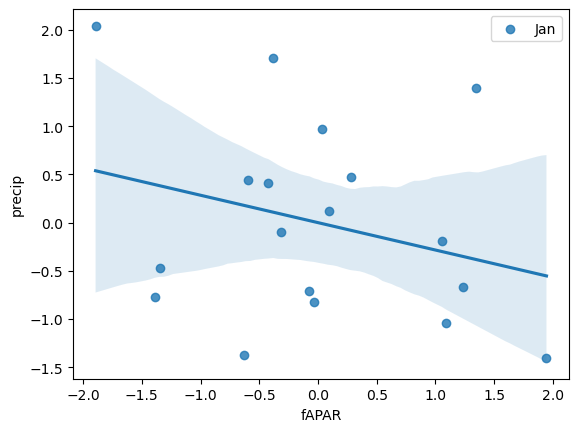

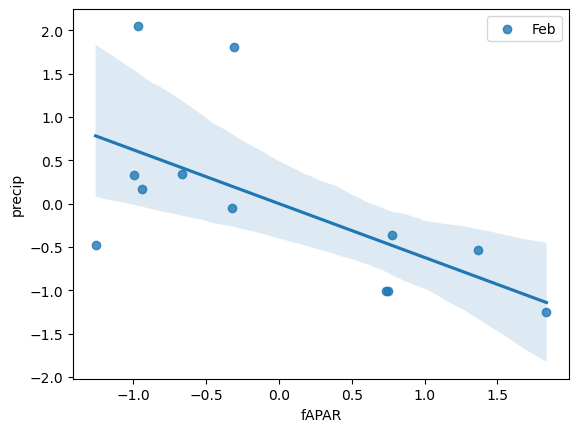

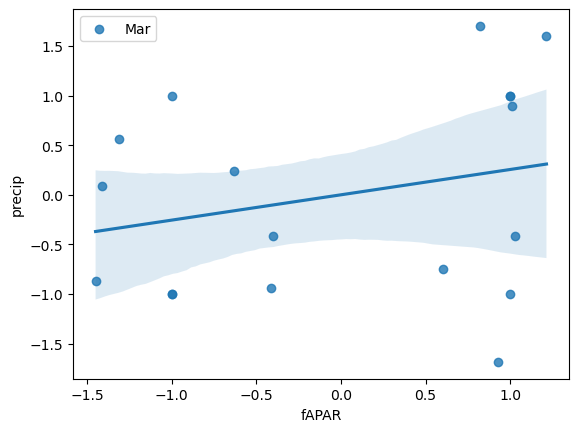

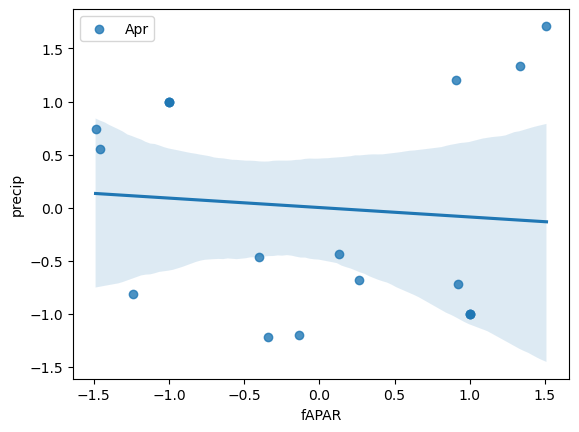

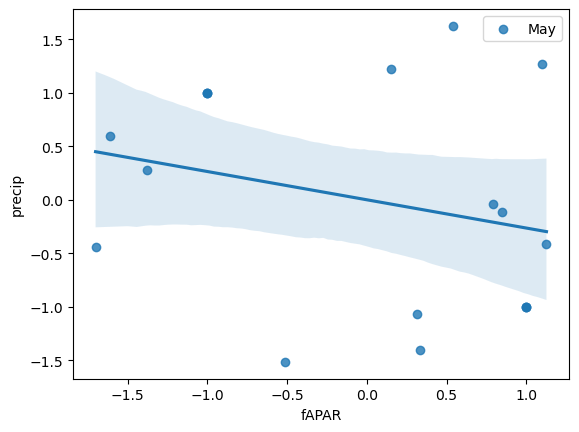

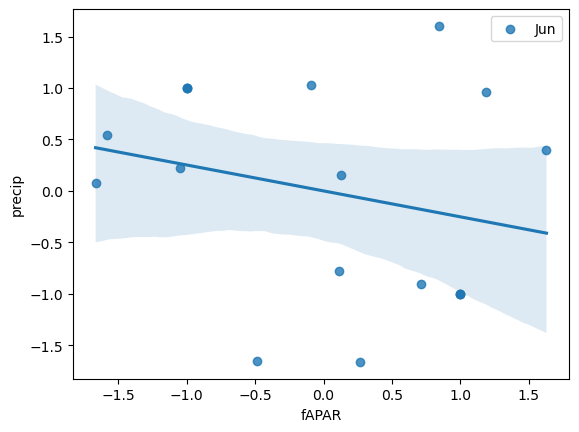

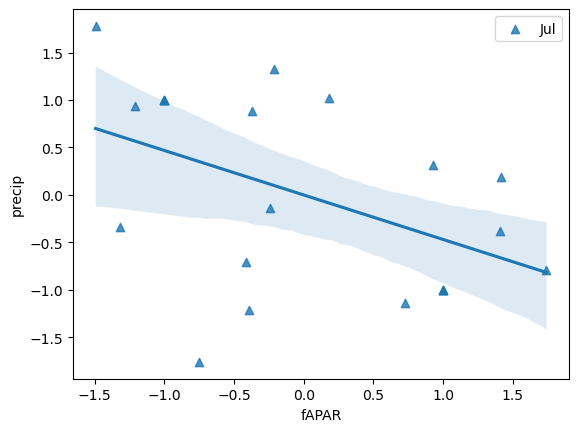

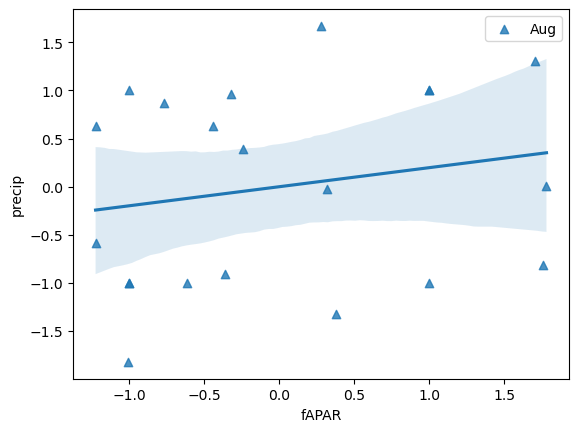

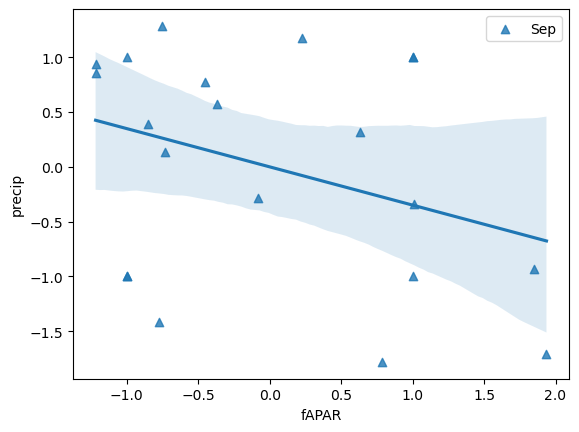

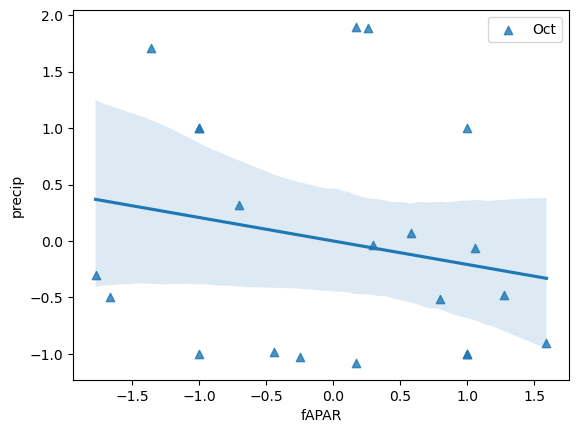

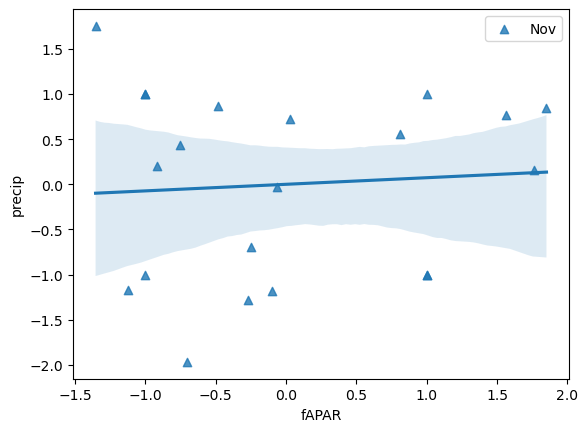

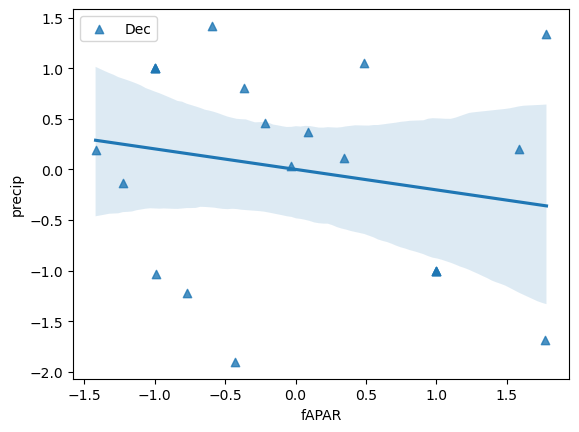

<Figure size 640x480 with 0 Axes>

In [14]:
mon = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
shp = ['o','o','o','o','o','o','^','^','^','^','^','^']
for m in range(1,13):
    df_zscore_m = df_zscore[df_zscore.index.month == m]
    sns.regplot(data=df_zscore_m, x="fAPAR", y="precip",label=mon[m-1],marker=shp[m-1])
    plt.legend(ncol=2)
    plt.show()
    plt.clf()

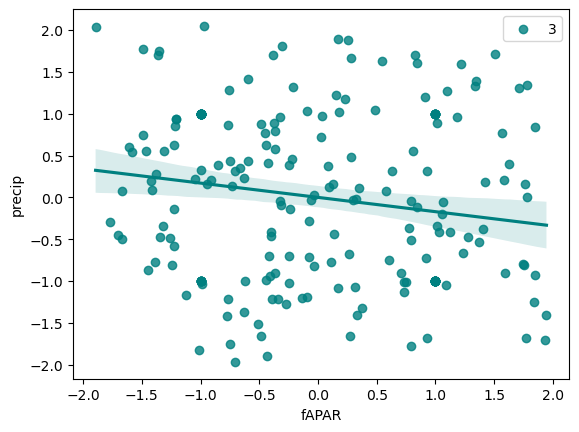

In [15]:
df_zscore_seas = df_zscore#[df_zscore.index.month.isin([8])]
#df_zscore_seas = df_zscore[(df_zscore.index.dayofyear>2) & (df_zscore.index.dayofyear<62)]
sns.regplot(data=df_zscore_seas, x="fAPAR", y="precip",label='3',ci=95,color='teal')
plt.legend()

In [16]:
fit_results = sm.OLS(df_zscore_seas['fAPAR'], df_zscore_seas['precip']).fit()
print(fit_results.summary())

                                 OLS Regression Results                                
Dep. Variable:                  fAPAR   R-squared (uncentered):                   0.029
Model:                            OLS   Adj. R-squared (uncentered):              0.025
Method:                 Least Squares   F-statistic:                              6.829
Date:                Fri, 22 May 2026   Prob (F-statistic):                     0.00957
Time:                        17:08:38   Log-Likelihood:                         -320.14
No. Observations:                 228   AIC:                                      642.3
Df Residuals:                     227   BIC:                                      645.7
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------